In [29]:
from search import *
from notebook import psource, heatmap, gaussian_kernel, show_map, final_path_colors, display_visual, plot_NQueens

# Needed to hide warnings in the matplotlib sections
import warnings
warnings.filterwarnings("ignore")

In [2]:
%matplotlib inline
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import lines

from ipywidgets import interact
import ipywidgets as widgets
from IPython.display import display
import time

In [3]:
romania_map = UndirectedGraph(dict(
    Arad=dict(Zerind=75, Sibiu=140, Timisoara=118),
    Bucharest=dict(Urziceni=85, Pitesti=101, Giurgiu=90, Fagaras=211),
    Craiova=dict(Drobeta=120, Rimnicu=146, Pitesti=138),
    Drobeta=dict(Mehadia=75),
    Eforie=dict(Hirsova=86),
    Fagaras=dict(Sibiu=99),
    Hirsova=dict(Urziceni=98),
    Iasi=dict(Vaslui=92, Neamt=87),
    Lugoj=dict(Timisoara=111, Mehadia=70),
    Oradea=dict(Zerind=71, Sibiu=151),
    Pitesti=dict(Rimnicu=97),
    Rimnicu=dict(Sibiu=80),
    Urziceni=dict(Vaslui=142)))

romania_map.locations = dict(
    Arad=(91, 492), Bucharest=(400, 327), Craiova=(253, 288),
    Drobeta=(165, 299), Eforie=(562, 293), Fagaras=(305, 449),
    Giurgiu=(375, 270), Hirsova=(534, 350), Iasi=(473, 506),
    Lugoj=(165, 379), Mehadia=(168, 339), Neamt=(406, 537),
    Oradea=(131, 571), Pitesti=(320, 368), Rimnicu=(233, 410),
    Sibiu=(207, 457), Timisoara=(94, 410), Urziceni=(456, 350),
    Vaslui=(509, 444), Zerind=(108, 531))

In [4]:
romania_problem = GraphProblem('Arad', 'vaslui', romania_map)

In [5]:
romania_locations = romania_map.locations
print(romania_locations)

{'Arad': (91, 492), 'Bucharest': (400, 327), 'Craiova': (253, 288), 'Drobeta': (165, 299), 'Eforie': (562, 293), 'Fagaras': (305, 449), 'Giurgiu': (375, 270), 'Hirsova': (534, 350), 'Iasi': (473, 506), 'Lugoj': (165, 379), 'Mehadia': (168, 339), 'Neamt': (406, 537), 'Oradea': (131, 571), 'Pitesti': (320, 368), 'Rimnicu': (233, 410), 'Sibiu': (207, 457), 'Timisoara': (94, 410), 'Urziceni': (456, 350), 'Vaslui': (509, 444), 'Zerind': (108, 531)}


In [6]:
# node colors, node positions and node label positions
node_colors = {node: 'pink' for node in romania_map.locations.keys()}
node_positions = romania_map.locations
node_label_pos = { k:[v[0],v[1]-10]  for k,v in romania_map.locations.items() }
edge_weights = {(k, k2) : v2 for k, v in romania_map.graph_dict.items() for k2, v2 in v.items()}

romania_graph_data = {  'graph_dict' : romania_map.graph_dict,
                        'node_colors': node_colors,
                        'node_positions': node_positions,
                        'node_label_positions': node_label_pos,
                         'edge_weights': edge_weights
                     }

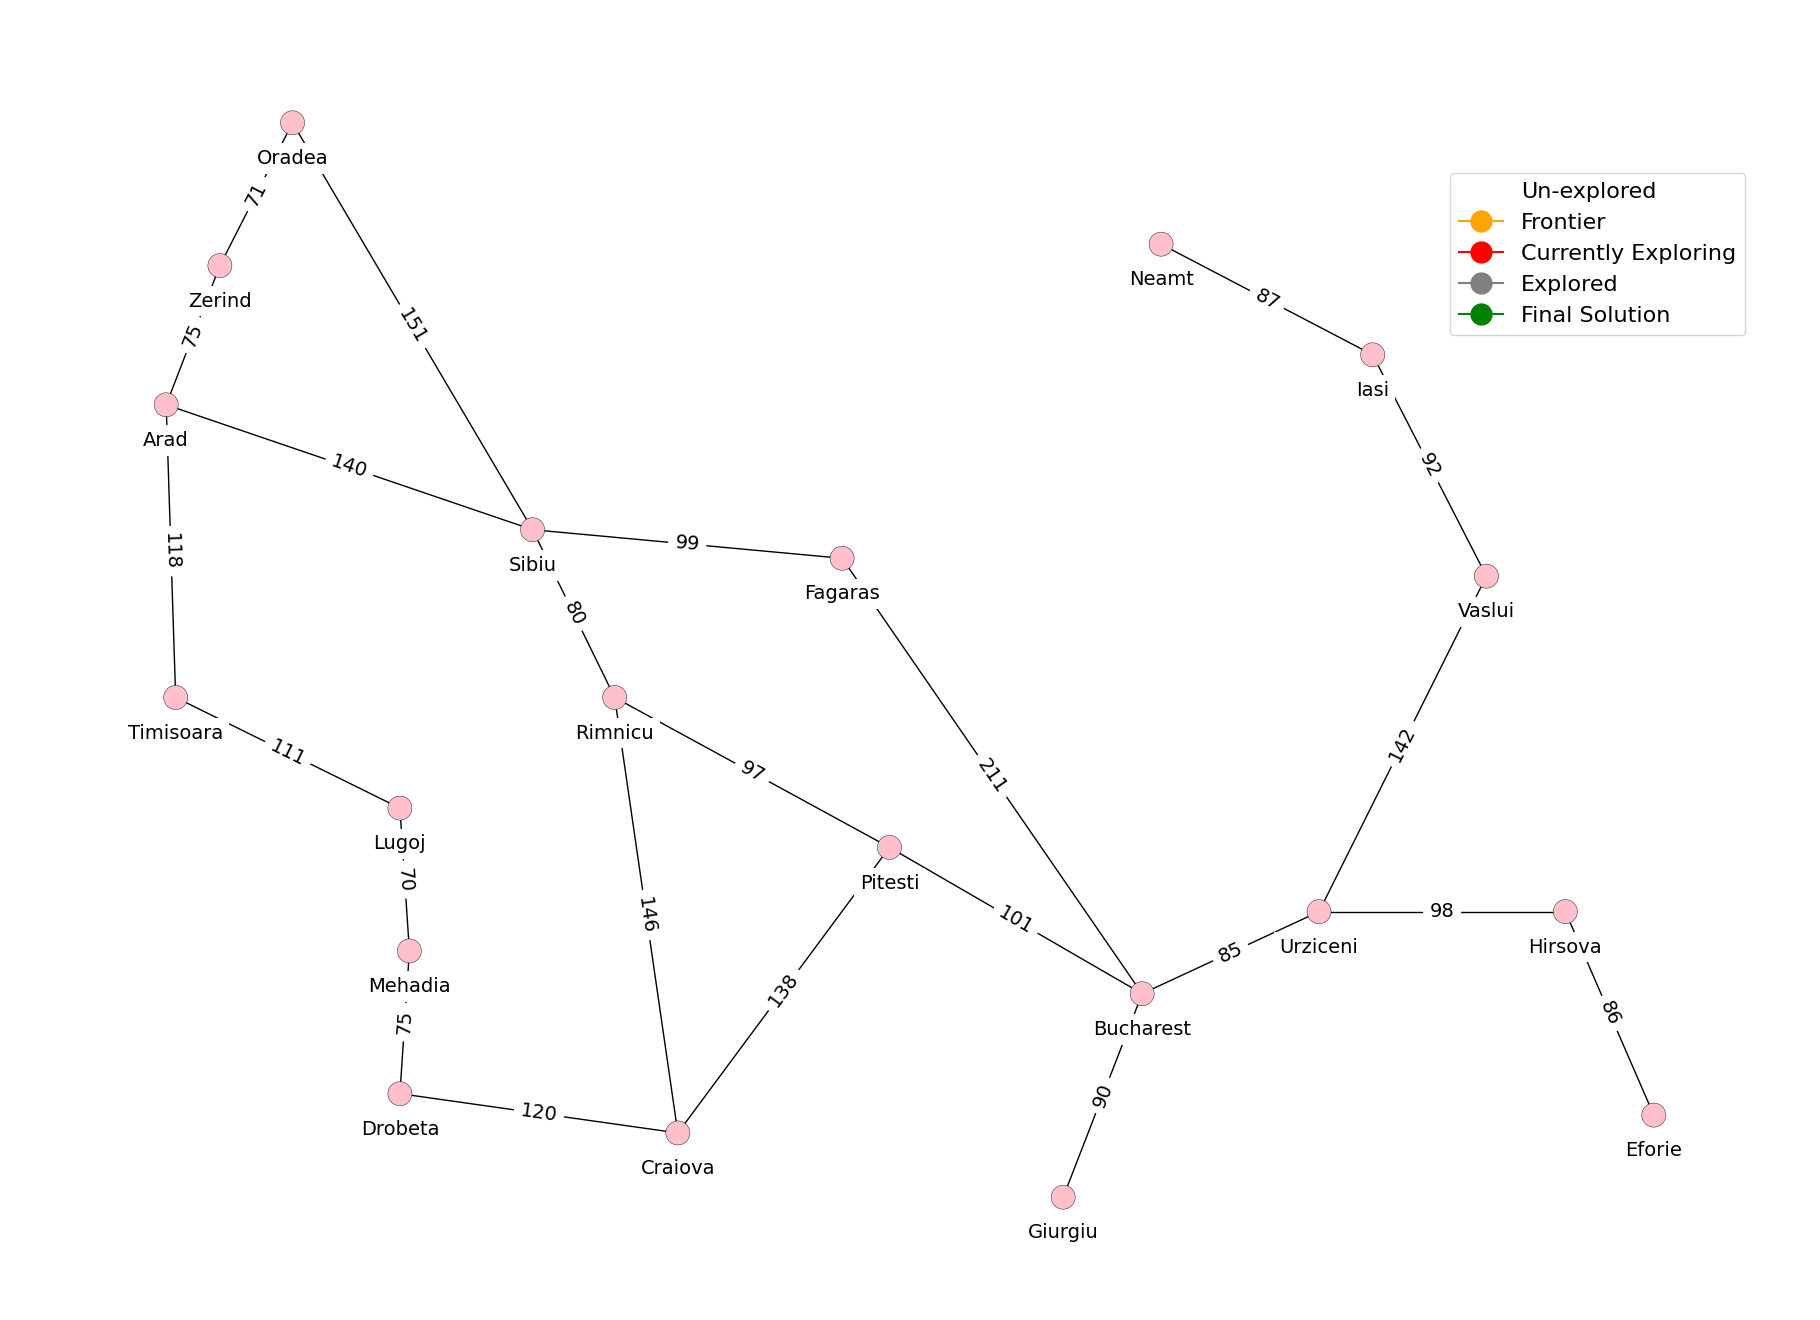

In [7]:
show_map(romania_graph_data)

**1. BREADTH-FIRST TREE SEARCH**

In [15]:
def tree_breadth_search_for_vis(problem):
    """Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    Don't worry about repeated paths to a state. [Figure 3.7]"""
    
    # we use these two variables at the time of visualisations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    #Adding first node to the queue
    frontier = deque([Node(problem.initial)])
    
    node_colors[Node(problem.initial).state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))
    
    while frontier:
        #Popping first node of queue
        node = frontier.popleft()
        
        # modify the currently searching node to red
        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
        if problem.goal_test(node.state):
            # modify goal node to green after reaching the goal
            node_colors[node.state] = "green"
            iterations += 1
            all_node_colors.append(dict(node_colors))
            return(iterations, all_node_colors, node)
        
        frontier.extend(node.expand(problem))
           
        for n in node.expand(problem):
            node_colors[n.state] = "orange"
            iterations += 1
            all_node_colors.append(dict(node_colors))

        # modify the color of explored nodes to gray
        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
    return None

def breadth_first_tree_search(problem):
    "Search the shallowest nodes in the search tree first."
    iterations, all_node_colors, node = tree_breadth_search_for_vis(problem)
    return(iterations, all_node_colors, node)

In [16]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
a, b, c = breadth_first_tree_search(romania_problem)
display_visual(romania_graph_data, user_input=False, 
               algorithm=breadth_first_tree_search, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**
โค้ดสร้างคิว frontier ด้วย deque และใส่โหนดเริ่มต้นคือเมือง Arad ลงไป พร้อมกำหนดสีเริ่มต้นให้ทุกโหนดเป็นสีชมพูและเปลี่ยนโหนดในคิวเป็นสีส้ม จากนั้นดึงโหนดหน้าสุดออกจากคิวด้วย popleft() และเปลี่ยนสีโหนดที่กำลังพิจารณาเป็นสีแดง จากนั้นตรวจสอบว่าโหนดปัจจุบันเป็นเมืองเป้าหมาย (Goal Node) ด้วย problem.goal_test() หรือไม่
หากใช่: เปลี่ยนสีโหนดเป็นสีเขียว บันทึกจำนวนรอบ และคืนค่าผลลัพธ์เพื่อจบการทำงานทันที
หากไม่ใช่: เรียกใช้ node.expand(problem) เพื่อขยายโหนดลูกในระดับถัดไป นำโหนดลูกทั้งหมดใส่ต่อท้ายคิว (frontier.extend), เปลี่ยนสีโหนดลูกเป็นสีส้ม แล้วเปลี่ยนสีโหนดปัจจุบันที่ตรวจเสร็จแล้วเป็นสีเทา

สรุป:การค้นหาใช้เวลาและจำนวนรอบค่อนข้างมาก เนื่องจากเป็นการค้นหาตามแนวกว้างที่ต้องสำรวจโหนดลูกในระดับความลึกเดียวกันให้ครบทีละขั้น (Level-by-level) ก่อนขยับไประดับถัดไป แม้จะใช้เวลาประมวลผลสูง แต่การันตีได้ว่าจะพบเส้นทางคำตอบที่มี จำนวนขั้นตอน(Steps) สั้นที่สุด ในการเดินทางไปยังเมืองเป้าหมาย

**2. Depth First Tree Search**

In [14]:
def tree_depth_search_for_vis(problem):
    """Search through the successors of a problem to find a goal."""
    iterations = 0
    all_node_colors = []
    node_colors = {k: 'pink' for k in problem.graph.nodes()}

    start_node = Node(problem.initial)          # was problem.initail
    frontier = [start_node]
    reached = {start_node.state}

    node_colors[start_node.state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))

    while frontier:
        node = frontier.pop()                   # pop from end -> stack -> DFS

        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))

        if problem.goal_test(node.state):
            node_colors[node.state] = "green"
            iterations += 1
            all_node_colors.append(dict(node_colors))
            return (iterations, all_node_colors, node)

        for child in node.expand(problem):
            if child.state not in reached:
                reached.add(child.state)
                frontier.append(child)
                node_colors[child.state] = "orange"
                iterations += 1
                all_node_colors.append(dict(node_colors))

        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))

    return None


def depth_first_tree_search(problem):
    "Search the deepest nodes in the search tree first."
    return tree_depth_search_for_vis(problem)

In [9]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=depth_first_tree_search, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**
กลไกหลัก: อัลกอริทึมจะเน้น ค้นหาลงไปในแนวลึกที่สุดของกิ่งนั้นๆ ก่อน เมื่อไปจนสุดทางแล้วไม่พบคำตอบ จึงค่อยย้อนกลับมา (Backtrack) เพื่อไปค้นหากิ่งอื่นต่อ
หน่วยความจำ (Space Complexity): ใช้พื้นที่หน่วยความจำน้อยกว่า BFS อย่างมาก เพราะบันทึกเฉพาะโหนดในเส้นทางปัจจุบันลงใน Stack เท่านั้น
ข้อจำกัด (Tree Search Warning): เนื่องจากเป็น Tree Search (ไม่มีการเก็บบันทึก Visited States หรือโหนดที่เคยไปมาแล้ว) หากกราฟมีลักษณะเป็นวงวน (Cycle/Loop) อัลกอริทึมนี้อาจติดอยู่ใน Infinite Loop หรือค้นหาลงไปในกิ่งที่ลึกไม่สิ้นสุดจนโปรแกรมค้างได้
การันตีคำตอบ (Optimality): ไม่การันตีว่าจะได้เส้นทางที่สั้นที่สุด (Not Optimal) เพราะเมื่ออัลกอริทึมเจอเส้นทางใดที่ไปถึง Goal Node ก่อน มันจะหยุดและตอบเส้นทางนั้นทันที แม้ว่าจะมีเส้นทางอื่นที่ใช้ Step น้อยกว่าก็ตาม

**3. Breadth First Search**

In [11]:
def breadth_first_search_graph(problem):
    "[Figure 3.11]"
    
    # we use these two variables at the time of visualisations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    node = Node(problem.initial)
    
    node_colors[node.state] = "red"
    iterations += 1
    all_node_colors.append(dict(node_colors))
      
    if problem.goal_test(node.state):
        node_colors[node.state] = "green"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        return(iterations, all_node_colors, node)
    
    frontier = deque([node])
    
    # modify the color of frontier nodes to blue
    node_colors[node.state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))
        
    explored = set()
    while frontier:
        node = frontier.popleft()
        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
        explored.add(node.state)     
        
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                if problem.goal_test(child.state):
                    node_colors[child.state] = "green"
                    iterations += 1
                    all_node_colors.append(dict(node_colors))
                    return(iterations, all_node_colors, child)
                frontier.append(child)

                node_colors[child.state] = "orange"
                iterations += 1
                all_node_colors.append(dict(node_colors))
                    
        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))
    return None

In [12]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=breadth_first_search_graph, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**
แก้จุดอ่อนของ Tree Search: การเพิ่ม explored set เข้ามา ช่วยป้องกันไม่ให้อัลกอริทึมเข้าไปสำรวจโหนดเดิมซ้ำ ทำให้ไม่ติดอยู่ใน Infinite Loop หรือวงวนของกราฟ
ประสิทธิภาพของ Early Goal Test: ตรวจสอบเป้าหมายทันทีที่สร้างโหนดลูกขึ้นมา (ก่อนที่จะนำเข้าคิว) ทำให้พบคำตอบเร็วขึ้นและประหยัดจำนวน Iteration ได้ดีกว่าการตรวจเมื่อดึงออกจากคิว
การันตีคำตอบ (Completeness & Optimality):
Completeness: ค้นพบคำตอบแน่นอนหากมีเส้นทางไปยัง Goal Node
Optimality: ได้เส้นทางที่มีจำนวนขั้นตอน (Steps) สั้นที่สุดเสมอ ในกรณีที่ทุก Edge มีน้ำหนักเท่ากัน

**4. Depth First Graph Search**

In [17]:
def graph_search_for_vis(problem):
    """Search through the successors of a problem to find a goal.
    The argument frontier should be an empty queue.
    If two paths reach a state, only use the first one. [Figure 3.7]"""
    # we use these two variables at the time of visualisations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    frontier = [(Node(problem.initial))]
    explored = set()
    
    # modify the color of frontier nodes to orange
    node_colors[Node(problem.initial).state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))
      
    while frontier:
        # Popping first node of stack
        node = frontier.pop()
        
        # modify the currently searching node to red
        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
        if problem.goal_test(node.state):
            # modify goal node to green after reaching the goal
            node_colors[node.state] = "green"
            iterations += 1
            all_node_colors.append(dict(node_colors))
            return(iterations, all_node_colors, node)
        
        explored.add(node.state)
        frontier.extend(child for child in node.expand(problem)
                        if child.state not in explored and
                        child not in frontier)
        
        for n in frontier:
            # modify the color of frontier nodes to orange
            node_colors[n.state] = "orange"
            iterations += 1
            all_node_colors.append(dict(node_colors))

        # modify the color of explored nodes to gray
        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
    return None


def depth_first_graph_search(problem):
    """Search the deepest nodes in the search tree first."""
    iterations, all_node_colors, node = graph_search_for_vis(problem)
    return(iterations, all_node_colors, node)

In [ ]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=depth_first_graph_search, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**5. Best First Graph Search**

In [14]:
def best_first_graph_search_for_vis(problem, f):
    """Search the nodes with the lowest f scores first.
    You specify the function f(node) that you want to minimize; for example,
    if f is a heuristic estimate to the goal, then we have greedy best
    first search; if f is node.depth then we have breadth-first search.
    There is a subtlety: the line "f = memoize(f, 'f')" means that the f
    values will be cached on the nodes as they are computed. So after doing
    a best first search you can examine the f values of the path returned."""
    
    # we use these two variables at the time of visualisations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    f = memoize(f, 'f')
    node = Node(problem.initial)
    
    node_colors[node.state] = "red"
    iterations += 1
    all_node_colors.append(dict(node_colors))
    
    if problem.goal_test(node.state):
        node_colors[node.state] = "green"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        return(iterations, all_node_colors, node)
    
    frontier = PriorityQueue('min', f)
    frontier.append(node)
    
    node_colors[node.state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))
    
    explored = set()
    while frontier:
        node = frontier.pop()
        
        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
        if problem.goal_test(node.state):
            node_colors[node.state] = "green"
            iterations += 1
            all_node_colors.append(dict(node_colors))
            return(iterations, all_node_colors, node)
        
        explored.add(node.state)
        for child in node.expand(problem):
            if child.state not in explored and child not in frontier:
                frontier.append(child)
                node_colors[child.state] = "orange"
                iterations += 1
                all_node_colors.append(dict(node_colors))
            elif child in frontier:
                incumbent = frontier[child]
                if f(child) < incumbent:
                    del frontier[child]
                    frontier.append(child)
                    node_colors[child.state] = "orange"
                    iterations += 1
                    all_node_colors.append(dict(node_colors))

        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))
    return None

In [15]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
f_func = lambda n: romania_problem.h(n)

display_visual(romania_graph_data, user_input=False, 
               algorithm=lambda prob: best_first_graph_search_for_vis(prob, f_func), 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**6. Uniform Cost Search**

In [16]:
def uniform_cost_search_graph(problem):
    "[Figure 3.14]"
    #Uniform Cost Search uses Best First Search algorithm with f(n) = g(n)
    iterations, all_node_colors, node = best_first_graph_search_for_vis(problem, lambda node: node.path_cost)
    return(iterations, all_node_colors, node)


In [17]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=uniform_cost_search_graph, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

แนวทางการค้นหา: ค้นหาและขยายโหนดตาม ค่าใช้จ่ายสะสมต่ำสุด (Lowest Path Cost) จากจุดเริ่มต้น ไม่ใช่ค้นหาตามความลึกหรือจำนวน Step
ความสมบูรณ์ (Completeness): มี (Yes) — หากค่าใช้จ่ายของทุกเส้นทางมีค่าเป็นบวก อัลกอริทึมจะค้นหาเจอคำตอบเสมอคำตอบที่ดีที่สุด 
(Optimality): มี (Yes) — รับประกันว่าจะได้ เส้นทางที่ประหยัด/มีค่าใช้จ่ายน้อยที่สุดเสมอ (Cheapest Path) เนื่องจากอัลกอริทึมจะเลือกขยายเส้นทางที่สั้นที่สุด ณ ตอนนั้นก่อนเสมอ
ข้อเปรียบเทียบกับ BFS: หากน้ำหนักหรือค่าใช้จ่ายของทุก Edge เท่ากันทั้งหมด (Step Cost เท่ากันทุกเส้นทาง) UCS จะทำงานเหมือนกับ Breadth-First Search (BFS) ทุกประการ

**7. Depth Limited Search**

In [18]:
def depth_limited_search_graph(problem, limit = -1):
    '''
    Perform depth first search of graph g.
    if limit >= 0, that is the maximum depth of the search.
    '''
    # we use these two variables at the time of visualisations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    frontier = [Node(problem.initial)]
    explored = set()
    
    cutoff_occurred = False
    node_colors[Node(problem.initial).state] = "orange"
    iterations += 1
    all_node_colors.append(dict(node_colors))
      
    while frontier:
        # Popping first node of queue
        node = frontier.pop()
        
        # modify the currently searching node to red
        node_colors[node.state] = "red"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
        if problem.goal_test(node.state):
            # modify goal node to green after reaching the goal
            node_colors[node.state] = "green"
            iterations += 1
            all_node_colors.append(dict(node_colors))
            return(iterations, all_node_colors, node)

        elif limit >= 0:
            cutoff_occurred = True
            limit += 1
            all_node_colors.pop()
            iterations -= 1
            node_colors[node.state] = "gray"

        
        explored.add(node.state)
        frontier.extend(child for child in node.expand(problem)
                        if child.state not in explored and
                        child not in frontier)
        
        for n in frontier:
            limit -= 1
            # modify the color of frontier nodes to orange
            node_colors[n.state] = "orange"
            iterations += 1
            all_node_colors.append(dict(node_colors))

        # modify the color of explored nodes to gray
        node_colors[node.state] = "gray"
        iterations += 1
        all_node_colors.append(dict(node_colors))
        
    return 'cutoff' if cutoff_occurred else None


def depth_limited_search_for_vis(problem):
    """Search the deepest nodes in the search tree first."""
    iterations, all_node_colors, node = depth_limited_search_graph(problem)
    return(iterations, all_node_colors, node)     

In [19]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=depth_limited_search_for_vis, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

แนวทางการค้นหา: ทำงานเหมือนกับ Depth-First Search (DFS) คือค้นหาลงไปในแนวลึกก่อน แต่เพิ่มข้อจำกัดความลึกสูงสุด เพื่อป้องกันไม่ให้อัลกอริทึมลงไปในกิ่งที่ลึกไม่สิ้นสุด
การแก้ปัญหา Infinite Loop: การรันบน Graph Search (มี explored set) ร่วมกับการจำกัดความลึก ช่วยแก้ปัญหาการติดลูปซ้ำและการค้นหาไร้ขอบเขตของ DFS แบบปกติ
ข้อจำกัดเรื่องคำตอบ:ความสมบูรณ์ (Completeness): ไม่สมบูรณ์ (No) หากคำตอบอยู่นอกเหนือขีดจำกัดความลึกที่กำหนด ($d > l$)
คำตอบที่ดีที่สุด (Optimality): ไม่การันตีว่าจะได้เส้นทางที่ดีที่สุด (Not Optimal) เพราะเมื่อพบเป้าหมายแรกในขอบเขตความลึกจะหยุดการค้นหาทันที

**8. Iterative Deepening Search**

In [20]:
def iterative_deepening_search_for_vis(problem):
    for depth in range(sys.maxsize):
        iterations, all_node_colors, node=depth_limited_search_for_vis(problem)
        if iterations:
            return (iterations, all_node_colors, node)

In [21]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=iterative_deepening_search_for_vis, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

จุดเด่นหลัก: รวมข้อดีของ BFS (ได้คำตอบที่สั้นที่สุด) และ DFS (ใช้หน่วยความจำน้อย) เข้าด้วยกัน
การทำงาน: ทำการค้นหาในแนวลึก (DFS) ซ้ำๆ โดยขยายขอบเขตความลึกสูงสุดเพิ่มขึ้นทีละ 1 ระดับไปเรื่อยๆ จนกว่าจะเจอคำตอบ
ความสมบูรณ์ (Completeness): มี (Yes) — หากมีคำตอบอยู่จริง จะหาพบแน่นอนเนื่องจากเพิ่มความลึกขึ้นทีละขั้น
คำตอบที่ดีที่สุด (Optimality): มี (Yes) — การันตีว่าจะได้เส้นทางที่สั้นที่สุด (จำนวน Step น้อยที่สุด) เหมือนกับ BFSหน่วยความจำ (Space Complexity): $O(bd)$ — ประหยัดพื้นที่ RAM อย่างมากเพราะใช้หน่วยความจำแบบ DFS ในแต่ละรอบความลึก

**9. Greedy Best First Search**

In [22]:
def greedy_best_first_search(problem, h=None):
    """Greedy Best-first graph search is an informative searching algorithm with f(n) = h(n).
    You need to specify the h function when you call best_first_search, or
    else in your Problem subclass."""
    h = memoize(h or problem.h, 'h')
    iterations, all_node_colors, node = best_first_graph_search_for_vis(problem, lambda n: h(n))
    return(iterations, all_node_colors, node)


In [ ]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
romania_problem.h = lambda node: romania_map.locations[node.state] # หรือใช้สูตร distance ที่เตรียมไว้ใน problem
display_visual(romania_graph_data, user_input=False, 
               algorithm=greedy_best_first_search, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

แนวทางการค้นหา: มุ่งหน้าไปยังเป้าหมายอย่างเดียว ("ตะกละ" หรือ Greedy) โดยเลือกโหนดที่ดูเหมือนจะใกล้เป้าหมายที่สุด ณ ตอนนั้น โดยไม่สนใจค่าใช้จ่ายที่เดินผ่านมาจากจุดเริ่มต้น ($g(n)$)
ความเร็วในการค้นหา: มักจะหาคำตอบพบได้เร็วมากเมื่อเทียบกับ Uninformed Search (เช่น BFS หรือ DFS) เนื่องจากมี Heuristic ช่วยนำทาง
ความสมบูรณ์ (Completeness): ไม่สมบูรณ์ (No) บน Tree Search (อาจติด Infinite Loop ได้) แต่บน Graph Search จะสมบูรณ์หากพื้นที่การค้นหาเป็นแบบจำกัด (Finite Space)
คำตอบที่ดีที่สุด (Optimality): ไม่การันตี (No) — ได้เส้นทางคำตอบเร็วแต่อาจไม่ใช่เส้นทางที่สั้นที่สุดหรือประหยัดที่สุด เนื่องจากคำนวณจากค่าประมาณการ $h(n)$ เพียงอย่างเดียว

**10. A\*-Search**

In [24]:
def astar_search_graph(problem, h=None):
    """A* search is best-first graph search with f(n) = g(n)+h(n).
    You need to specify the h function when you call astar_search, or
    else in your Problem subclass."""
    h = memoize(h or problem.h, 'h')
    iterations, all_node_colors, node = best_first_graph_search_for_vis(problem, 
                                                                lambda n: n.path_cost + h(n))
    return(iterations, all_node_colors, node)


In [ ]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False, 
               algorithm=astar_search_graph, 
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

แนวทางการค้นหา: รวมข้อดีของ Uniform-Cost Search ($g$) และ Greedy Best-First Search ($h$) เข้าด้วยกัน เพื่อประเมินทั้งค่าใช้จ่ายที่เกิดขึ้นจริงและระยะทางที่เหลืออยู่

ความสมบูรณ์ (Completeness): มี (Yes) — ค้นพบคำตอบเสมอหากมีเส้นทางไปยังเป้าหมาย

คำตอบที่ดีที่สุด (Optimality): มี (Yes) — การันตีว่าจะได้เส้นทางที่มีค่าใช้จ่ายต่ำที่สุด (Cheapest Path) ภายใต้เงื่อนไขว่า Heuristic ต้องเป็น Admissible (ไม่ประเมินค่าสูงเกินจริง $h(n) \le h^*(n)$)

ประสิทธิภาพ: เป็นหนึ่งในอัลกอริทึมค้นหาที่มีประสิทธิภาพสูงที่สุด เพราะค้นหาเจอป้าหมายได้เร็วโดยไม่ต้องเสียเวลาสำรวจกิ่งที่ไม่จำเป็น

**11. Recursive Best First Search**

In [30]:
infinity = float('inf')
def recursive_best_first_search_for_vis(problem, h=None):
    """[Figure 3.26] Recursive best-first search"""
    # we use these two variables at the time of visualizations
    iterations = 0
    all_node_colors = []
    node_colors = {k : 'pink' for k in problem.graph.nodes()}
    
    h = memoize(h or problem.h, 'h')
    
    def RBFS(problem, node, flimit):
        nonlocal iterations
        def color_city_and_update_map(node, color):
            node_colors[node.state] = color
            nonlocal iterations
            iterations += 1
            all_node_colors.append(dict(node_colors))
            
        if problem.goal_test(node.state):
            color_city_and_update_map(node, 'green')
            return (iterations, all_node_colors, node), 0  # the second value is immaterial
        
        successors = node.expand(problem)
        if len(successors) == 0:
            color_city_and_update_map(node, 'gray')
            return (iterations, all_node_colors, None), infinity
        
        for s in successors:
            color_city_and_update_map(s, 'orange')
            s.f = max(s.path_cost + h(s), node.f)
            
        while True:
            # Order by lowest f value
            successors.sort(key=lambda x: x.f)
            best = successors[0]
            if best.f > flimit:
                color_city_and_update_map(node, 'gray')
                return (iterations, all_node_colors, None), best.f
            
            if len(successors) > 1:
                alternative = successors[1].f
            else:
                alternative = infinity
                
            node_colors[node.state] = 'gray'
            node_colors[best.state] = 'red'
            iterations += 1
            all_node_colors.append(dict(node_colors))
            result, best.f = RBFS(problem, best, min(flimit, alternative))
            if result[2] is not None:
                color_city_and_update_map(node, 'green')
                return result, best.f
            else:
                color_city_and_update_map(node, 'red')
                
    node = Node(problem.initial)
    node.f = h(node)
    
    node_colors[node.state] = 'red'
    iterations += 1
    all_node_colors.append(dict(node_colors))
    result, bestf = RBFS(problem, node, infinity)
    return result

In [31]:
all_node_colors = []
romania_problem = GraphProblem('Arad', 'Vaslui', romania_map)
display_visual(romania_graph_data, user_input=False,
               algorithm=recursive_best_first_search_for_vis,
               problem=romania_problem)

interactive(children=(IntSlider(value=0, description='iteration', max=1), Output()), _dom_classes=('widget-int…

interactive(children=(ToggleButton(value=False, description='visualize'), Output()), _dom_classes=('widget-int…

**สรุปผลการทำงาน**

แนวทางการค้นหา: จำลองการทำงานของ Best-First Search (ค้นหาโหนดที่มีค่า $f$-cost ต่ำที่สุดก่อน) แต่เปลี่ยนมาใช้วิธีเรียกตัวเองแบบ Recursive Depth-First Search 

การบริหารจัดการหน่วยความจำ (Space Complexity): $O(bd)$ — ประหยัด RAM สูงมาก เนื่องจากใช้พื้นที่เก็บบันทึกข้อมูลเฉพาะเส้นทางปัจจุบันใน Recursion Stack เท่านั้น (เหมือน DFS)

การันตีคำตอบ (Completeness & Optimality):
    
    Completeness: มี (Yes) — หากค่า Heuristic เป็น Admissible
    
    Optimality: มี (Yes) — การันตีว่าจะได้เส้นทางที่มีค่าใช้จ่ายต่ำที่สุด (Cheapest Path) เท่ากับ A* Search

ข้อจำกัด: อาจเกิดการสลับกิ่งทำงานไปมาซ้ำ ๆ (Excessive Backtracking) เมื่อมีหลายกิ่งที่มีค่า $f$-cost ใกล้เคียงกัน ทำให้จำนวน Iteration และเวลาที่ใช้ประมวลผลเพิ่มขึ้นสูง